# Предсказание возраста посетителей сайтов для IT-компания «Йети»

#### Описание проекта

Построить  построить модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст

#### Тип задачи

Задача многоклассовой классификации

#### Цель модели

Предсказывать показывать рекламу на целевую аудиторию определённого возраста и снизить риски показа рекламы для взрослых несовершеннолетним.

#### Цель исследования

Добиться, чтобы модель максимально точно классифицировала пользователей по возрастным группам

#### Задачи исследования

1. Анализ данных и определение архитектуры решения
2. Обучение модели и оценка качества
3. Валидация
4. Подготовка отчета
5. Подготовка артефактов

#### Исходные данные

Датасеты, собранные из разных источников: лог посещений сайтов, активность взаимодействия с рекламой, данные по глубине переходов, данные по устройствам пользователей, данные по использованию облачных технологий.

#### Этапы исследования

1. Загрузка данных
2. Исследовательский анализ данных
3. Подготовка единого датасета
4. Предобработка данных
5. Отбор признаков
6. Обучение базовой модели
7. Подбор гиперпараметров
8. Обучение финальной модели
9. Отчет и выводы
10. Сохранение модели для продакшена

## Подготовка среды и библиотек

In [1]:
# Соберем все необходимые зависимости 

requirements = """
anyio==4.12.1
appnope==0.1.4
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
arrow==1.4.0
asttokens==3.0.1
async-lru==2.1.0
attrs==25.4.0
babel==2.17.0
beautifulsoup4==4.14.3
bleach==6.3.0
certifi==2026.1.4
cffi==2.0.0
charset-normalizer==3.4.4
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
debugpy==1.8.19
decorator==5.2.1
defusedxml==0.7.1
executing==2.2.1
fastjsonschema==2.21.2
fonttools==4.61.1
fqdn==1.5.1
h11==0.16.0
httpcore==1.0.9
httpx==0.28.1
idna==3.11
ipykernel==7.1.0
ipython==9.9.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
isoduration==20.11.0
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
json5==0.13.0
jsonpointer==3.0.0
jsonschema==4.26.0
jsonschema-specifications==2025.9.1
jupyter==1.1.1
jupyter-console==6.6.3
jupyter-events==0.12.0
jupyter-lsp==2.3.0
jupyter_client==8.8.0
jupyter_core==5.9.1
jupyter_server==2.17.0
jupyter_server_terminals==0.5.4
jupyterlab==4.5.2
jupyterlab_pygments==0.3.0
jupyterlab_server==2.28.0
jupyterlab_widgets==3.0.16
kiwisolver==1.4.9
lark==1.3.1
MarkupSafe==3.0.3
matplotlib==3.10.8
matplotlib-inline==0.2.1
mistune==3.2.0
mlxtend==0.24.0
nbclient==0.10.4
nbconvert==7.16.6
nbformat==5.10.4
nest-asyncio==1.6.0
notebook==7.5.2
notebook_shim==0.2.4
numpy==2.4.1
packaging==25.0
pandas==3.0.0
pandocfilters==1.5.1
parso==0.8.5
pexpect==4.9.0
phik==0.12.5
pillow==12.1.0
platformdirs==4.5.1
prometheus_client==0.24.1
prompt_toolkit==3.0.52
psutil==7.2.1
ptyprocess==0.7.0
pure_eval==0.2.3
pycparser==2.23
Pygments==2.19.2
pyparsing==3.3.2
python-dateutil==2.9.0.post0
python-json-logger==4.0.0
PyYAML==6.0.3
pyzmq==27.1.0
referencing==0.37.0
requests==2.32.5
rfc3339-validator==0.1.4
rfc3986-validator==0.1.1
rfc3987-syntax==1.1.0
rpds-py==0.30.0
scikit-learn==1.8.0
scipy==1.17.0
seaborn==0.13.2
Send2Trash==2.1.0
setuptools==80.9.0
six==1.17.0
soupsieve==2.8.1
stack-data==0.6.3
terminado==0.18.1
threadpoolctl==3.6.0
tinycss2==1.4.0
tornado==6.5.4
traitlets==5.14.3
typing_extensions==4.15.0
tzdata==2025.3
uri-template==1.3.0
urllib3==2.6.3
wcwidth==0.2.14
webcolors==25.10.0
webencodings==0.5.1
websocket-client==1.9.0
widgetsnbextension==4.0.15
"""

In [2]:
# Запишем зависимости в requirements.txt

with open("requirements.txt", "w") as f:
    f.write(requirements)

In [3]:
# Установим зависимости

!pip install -r requirements.txt

In [4]:
# Зафиксируем константы

RANDOM_STATE = 42
N_FOLDS = 5

In [105]:
# Импортируем все необходимые библиотеки

import ssl
import inspect
import urllib.request
import os
import joblib
import phik
import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_validate, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import VarianceThreshold, RFE, RFECV
from sklearn.metrics import precision_score, recall_score, average_precision_score, get_scorer_names, f1_score
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier

In [6]:
# Напишем функцию для загрузки файла локально или с сервера

def load_data(local_path, server_path):
    try:
        # Сначала пробуем локальный путь
        print(f"Пробуем загрузить из локального пути: {local_path}")
        df = pd.read_csv(local_path)
        print("Данные загружены из локального файла")
        return df
    
    except FileNotFoundError:
        # Если локальный файл не найден, пробуем серверный
        try:
            df = pd.read_csv(server_path)
            print("Данные загружены с сервера")
            return df
        except FileNotFoundError:
            print("Файл не найден ни в локально, ни на сервере")
            return None
        except Exception as e:
            print(f"Ошибка при загрузке с сервера: {e}")
            return None
    
    except Exception as e:
        print(f"Ошибка при загрузке из локального файла: {e}")
        return None

In [7]:
# Подготовим функционал по работе с неподтвержденными сертификатами

try:
    # Создаем небезопасный контекст
    ssl_context = ssl._create_unverified_context()
except AttributeError:
    # Альтернативный метод, если _create_unverified_context не работает
    ssl_context = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
    ssl_context.check_hostname = False
    ssl_context.verify_mode = ssl.CERT_NONE

# Создаем opener с нашим контекстом
https_handler = urllib.request.HTTPSHandler(context=ssl_context)
opener = urllib.request.build_opener(https_handler)
urllib.request.install_opener(opener)

In [8]:
# Путь к таблице users
local_users = '../datasets/ds_s13_users.csv'
server_users = 'https://code.s3.yandex.net/datasets/ds_s13_users.csv'

In [9]:
# Путь к таблице visits
local_visits = '../datasets/ds_s13_visits.csv'
server_visits = 'https://code.s3.yandex.net/datasets/ds_s13_visits.csv'

In [10]:
# Путь к таблице ads_activity
local_ads_activity = '../datasets/ads_activity.csv'
server_ads_activity = 'https://code.s3.yandex.net/datasets/ads_activity.csv'

In [11]:
# Путь к таблице surf_depth
local_surf_depth = '../datasets/surf_depth.csv'
server_surf_depth = 'https://code.s3.yandex.net/datasets/surf_depth.csv'

In [12]:
# Путь к таблице primary_device
local_primary_device = '../datasets/primary_device.csv'
server_primary_device = 'https://code.s3.yandex.net/datasets/primary_device.csv'

In [13]:
# Путь к таблице cloud_usage
local_cloud_usage = '../datasets/cloud_usage.csv'
server_cloud_usage = 'https://code.s3.yandex.net/datasets/cloud_usage.csv'

In [14]:
# Загружаем все таблицы в датасеты

df_users = load_data(local_users, server_users)
df_visits = load_data(local_visits, local_visits)
df_ads_activity = load_data(local_ads_activity, local_ads_activity)
df_surf_depth = load_data(local_surf_depth, server_surf_depth)
df_primary_device = load_data(local_primary_device, server_primary_device)
df_cloud_usage = load_data(local_cloud_usage, server_cloud_usage)

Пробуем загрузить из локального пути: ../datasets/ds_s13_users.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ds_s13_visits.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/ads_activity.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/surf_depth.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/primary_device.csv
Данные загружены из локального файла
Пробуем загрузить из локального пути: ../datasets/cloud_usage.csv
Данные загружены из локального файла


## Исследовательский анализ данных

### Краткая информация о загруженных датасетах

In [15]:
# Проверим информацию по получившимся датафреймам

# Данные о пользователях
df_users.info()

<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


Содержит две колонки, явных пропусков нет.

In [16]:
# Данные о посещенных сайтах
df_visits.info()

<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB


Датасет содержит 5 колонок, без явных пропусков

In [17]:
# Данные о взаимодействии с рекламой
df_ads_activity.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB


Содержит две колонки, явных пропусков нет.

In [18]:
# Данные о глубине переходов
df_surf_depth.info()

<class 'pandas.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     5715 non-null   str  
 1   surf_depth  5715 non-null   str  
dtypes: str(2)
memory usage: 89.4 KB


Содержит две колонки, явных пропусков нет.

In [19]:
# Данные об устройствах пользователей
df_primary_device.info()

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB


Содержит две колонки, явных пропусков нет.

In [20]:
# Данные об использовании облачных технологий
df_cloud_usage.info()

<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


Содержит две колонки, явных пропусков нет.

### Краткая информация о данных в датасетах

##### 2.2.1 Датасет с данными о возрастных категориях

In [21]:
# Количество уникальных user_id

df_users['user_id'].nunique()

5826

In [22]:
# Так как количество записей больше, чем число уникальных пользователей - в датасете есть дубликаты, необходимо их удалить
df_users_clean = df_users.drop_duplicates()

In [23]:
# Посмотрим распределение данных по возрастным категориям
df_users_clean['age_category'].value_counts(normalize=True)

age_category
4    0.303124
2    0.246996
3    0.215242
0    0.146413
1    0.088225
Name: proportion, dtype: float64

In [24]:
# Проверка
df_users_clean.info()

<class 'pandas.DataFrame'>
Index: 5826 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   age_category  5826 non-null   int64
dtypes: int64(1), str(1)
memory usage: 136.5 KB


##### 2.2.2 Датасет с данными о посещениях сайтов

In [25]:
# Количество уникальных user_id

df_visits['user_id'].nunique()

5826

In [26]:
# Сводная статистика
df_visits.describe()

,date,daytime,session_id,user_id,website_category
count,1065745,1065745,1065745,1065745,1065745
unique,14,4,1049995,5826,20
top,2025-11-13,день,404c2438-7a91-4537-bd77-8ea6a14b34ec,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,76599,389052,2,853,70260


In [27]:
# Уникальные значения по столбцам

df_visits['daytime'].unique()

<StringArray>
['вечер', 'день', 'ночь', 'утро']
Length: 4, dtype: str

In [28]:
# Проверим и удалим явные дубликаты в этой таблице

df_visits.duplicated().sum()

np.int64(15750)

In [29]:
# Удаляем

df_visits_clean = df_visits.drop_duplicates()

In [30]:
df_visits_clean['website_category'].unique()

<StringArray>
['Category 17', 'Category 19', 'Category 18', 'Category 20', 'Category 05',
 'Category 12', 'Category 03', 'Category 15', 'Category 10', 'Category 06',
 'Category 04', 'Category 09', 'Category 01', 'Category 11', 'Category 07',
 'Category 14', 'Category 08', 'Category 13', 'Category 02', 'Category 16']
Length: 20, dtype: str

In [31]:
df_visits_clean['date'].unique()

<StringArray>
['2025-11-01', '2025-11-02', '2025-11-03', '2025-11-04', '2025-11-05',
 '2025-11-06', '2025-11-07', '2025-11-08', '2025-11-09', '2025-11-10',
 '2025-11-11', '2025-11-12', '2025-11-13', '2025-11-14']
Length: 14, dtype: str

In [32]:
# Распределение просмотров по категориям в %

round(df_visits_clean['website_category'].value_counts(normalize=True) * 100, 2)

website_category
Category 03    6.58
Category 13    6.44
Category 05    5.69
Category 06    5.36
Category 08    5.26
Category 19    5.20
Category 07    5.13
Category 09    5.06
Category 01    4.99
Category 10    4.96
Category 15    4.90
Category 04    4.86
Category 20    4.80
Category 18    4.79
Category 12    4.76
Category 17    4.68
Category 16    4.35
Category 14    4.34
Category 02    4.17
Category 11    3.68
Name: proportion, dtype: float64

Создадим новые признаки в датасете по просмотрам: количество сессий на пользователя, наиболее активное время суток (по числу сессий), профиль пользователя по категориям. Сам датасет сгруппируем по user_id

In [33]:
# Посчитаем число сессий на пользователя и сохраним в отдельный датафрейм

df_visits_byuser = df_visits_clean.groupby('user_id')['session_id'].count().reset_index()
df_visits_byuser = df_visits_byuser.rename(columns={'session_id': 'session_count'})
# Проверка
df_visits_byuser.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   user_id        5826 non-null   str  
 1   session_count  5826 non-null   int64
dtypes: int64(1), str(1)
memory usage: 91.2 KB


In [34]:
# Определим профиль пользователя по категориям сайтов

cat_share = df_visits_clean.pivot_table(
    index='user_id',
    columns='website_category',
    values='session_id',
    aggfunc='count',
    fill_value=0
)

cat_share = cat_share.div(cat_share.sum(axis=1), axis=0)

cat_share.info()

<class 'pandas.DataFrame'>
Index: 5826 entries, 0010-5cf8f6b38a7b6c70a021-009dbcda to ffbf-71c28263b860736010d4-a0ee88f3
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Category 01  5826 non-null   float64
 1   Category 02  5826 non-null   float64
 2   Category 03  5826 non-null   float64
 3   Category 04  5826 non-null   float64
 4   Category 05  5826 non-null   float64
 5   Category 06  5826 non-null   float64
 6   Category 07  5826 non-null   float64
 7   Category 08  5826 non-null   float64
 8   Category 09  5826 non-null   float64
 9   Category 10  5826 non-null   float64
 10  Category 11  5826 non-null   float64
 11  Category 12  5826 non-null   float64
 12  Category 13  5826 non-null   float64
 13  Category 14  5826 non-null   float64
 14  Category 15  5826 non-null   float64
 15  Category 16  5826 non-null   float64
 16  Category 17  5826 non-null   float64
 17  Category 18  5826 non-null   float64
 18  C

In [35]:
# Определим профиль пользователя по времени суток

daytime_share = df_visits_clean.pivot_table(
    index="user_id",
    columns="daytime",
    values="session_id",
    aggfunc="count",
    fill_value=0
)

daytime_share = daytime_share.div(daytime_share.sum(axis=1), axis=0)

daytime_share.info()

<class 'pandas.DataFrame'>
Index: 5826 entries, 0010-5cf8f6b38a7b6c70a021-009dbcda to ffbf-71c28263b860736010d4-a0ee88f3
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   вечер   5826 non-null   float64
 1   день    5826 non-null   float64
 2   ночь    5826 non-null   float64
 3   утро    5826 non-null   float64
dtypes: float64(4)
memory usage: 227.6+ KB


In [36]:
# Количество уникальных категорий на пользователя

user_cat_count = df_visits_clean.groupby("user_id")["website_category"].nunique()
user_cat_count.info()

<class 'pandas.Series'>
Index: 5826 entries, 0010-5cf8f6b38a7b6c70a021-009dbcda to ffbf-71c28263b860736010d4-a0ee88f3
Series name: website_category
Non-Null Count  Dtype
--------------  -----
5826 non-null   int64
dtypes: int64(1)
memory usage: 91.0+ KB


In [37]:
# Соберем полученные данные в итоговый датафрейм

df_visits_fin = df_visits_byuser.merge(daytime_share, 
                                       on='user_id').merge(cat_share, 
                                                           on='user_id').merge(user_cat_count,
                                                                               on='user_id')

# Проверка

df_visits_fin.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5826 non-null   str    
 1   session_count     5826 non-null   int64  
 2   вечер             5826 non-null   float64
 3   день              5826 non-null   float64
 4   ночь              5826 non-null   float64
 5   утро              5826 non-null   float64
 6   Category 01       5826 non-null   float64
 7   Category 02       5826 non-null   float64
 8   Category 03       5826 non-null   float64
 9   Category 04       5826 non-null   float64
 10  Category 05       5826 non-null   float64
 11  Category 06       5826 non-null   float64
 12  Category 07       5826 non-null   float64
 13  Category 08       5826 non-null   float64
 14  Category 09       5826 non-null   float64
 15  Category 10       5826 non-null   float64
 16  Category 11       5826 non-null   float64
 17  Catego

In [38]:
# Проверим, не появилось ли дубликатов

df_visits_fin.duplicated(subset=['user_id']).sum()

np.int64(0)

##### 2.2.3 Датасет с данными об активности взаимодействия с рекламой

In [39]:
# Количество уникальных user_id

df_ads_activity['user_id'].nunique()

5593

In [40]:
# Количество записей превышает число уникальных значений user_id, значит в датасете есть дубликаты, необходимо избавиться от них

df_ads_activity_clean = df_ads_activity.drop_duplicates()

In [41]:
# Выведем уникальные значения для проверки

df_ads_activity_clean['ads_activity'].unique()

<StringArray>
['очень часто', 'редко', 'очень редко', 'умеренно', 'часто']
Length: 5, dtype: str

In [42]:
df_ads_activity_clean.info()

<class 'pandas.DataFrame'>
Index: 5593 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5593 non-null   str  
 1   ads_activity  5593 non-null   str  
dtypes: str(2)
memory usage: 131.1 KB


##### 2.2.4 Датасет с данными о глубине переходов по сайтам

In [43]:
# Количество уникальных user_id

df_surf_depth['user_id'].nunique()

5715

In [44]:
# В данном датасете собраны только уникальные user_id - дубликатов не обнаружено

In [45]:
# Выведем уникальные значения для проверки

df_surf_depth['surf_depth'].unique()

<StringArray>
['поверхностно', 'глубоко', 'средне']
Length: 3, dtype: str

##### 2.2.5 Датасет с данными об устройствах пользователей

In [46]:
# Количество уникальных user_id

df_primary_device['user_id'].nunique()

5669

In [47]:
# В данном датасете собраны только уникальные user_id - дубликатов не обнаружено

In [48]:
# Выведем уникальные значения для проверки

df_primary_device['primary_device'].unique()

<StringArray>
['смартфон', 'ПК', 'ноутбук', 'планшет']
Length: 4, dtype: str

##### 2.2.6 Датасет с данными об использовании облачных сервисов

In [49]:
# Количество уникальных user_id

df_cloud_usage['user_id'].nunique()

5680

In [50]:
# В данном датасете собраны только уникальные user_id - дубликатов не обнаружено

In [51]:
# Выведем распределение значений

df_cloud_usage['cloud_usage'].value_counts(normalize=True)

cloud_usage
True     0.519542
False    0.480458
Name: proportion, dtype: float64

##### 2.2.7 Получение единого датафрейма

In [52]:
# Напишем функцию, которая будет соединять разрозненные таблицы в единый датафрейм по ключу

def merge_dfs(base_df, dfs, key='user_id', how='left'):
    result = base_df.copy()
    
    for df in dfs:
        result = result.merge(df, on=key, how=how)
        
    return result

In [53]:
# Для дальнейшей работы соединим все данные в единый датафрейм с ключом user_id. Данные по визитам 

df_merged = merge_dfs(
    df_users_clean,
    [
        df_visits_fin,
        df_ads_activity_clean,
        df_surf_depth,
        df_primary_device,
        df_cloud_usage
    ])

df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5826 non-null   str    
 1   age_category      5826 non-null   int64  
 2   session_count     5826 non-null   int64  
 3   вечер             5826 non-null   float64
 4   день              5826 non-null   float64
 5   ночь              5826 non-null   float64
 6   утро              5826 non-null   float64
 7   Category 01       5826 non-null   float64
 8   Category 02       5826 non-null   float64
 9   Category 03       5826 non-null   float64
 10  Category 04       5826 non-null   float64
 11  Category 05       5826 non-null   float64
 12  Category 06       5826 non-null   float64
 13  Category 07       5826 non-null   float64
 14  Category 08       5826 non-null   float64
 15  Category 09       5826 non-null   float64
 16  Category 10       5826 non-null   float64
 17  Catego

In [54]:
# Проверка

df_merged.nunique()

user_id             5826
age_category           5
session_count        366
вечер               2718
день                2621
ночь                1926
утро                2472
Category 01         2087
Category 02         1939
Category 03         2385
Category 04         1998
Category 05         2080
Category 06         2042
Category 07         2019
Category 08         2102
Category 09         2045
Category 10         2010
Category 11         1827
Category 12         1995
Category 13         2347
Category 14         1966
Category 15         1997
Category 16         1982
Category 17         1999
Category 18         2084
Category 19         2072
Category 20         1999
website_category       6
ads_activity           5
surf_depth             3
primary_device         4
cloud_usage            2
dtype: int64

Полученный датасет содержит данные об 5826 пользователях, их возрастной категории, среднему числу интернет сессий, профилю пользователя в разрезе категорий сайтов и активности по времени суток. Часть колонок содержит пропуски, на этапе предобработки они будут обработаны. Также на основании логов пользовательской активности были добавлены новые признаки: число сессий, профиль пользователя по категории сайтов, по времени суток и число уникальных категорий у пользователя (широта интересов)

Целевая переменная: age_category - содержит 5 уникальных значений (диапазонов возрастных групп). Это говорит о том, что наша модель должна решать задачу многоклассовой классификации. Выведем соотношение классов в целевой переменной в виде графика

В рамках обработки пропусков предлагается следующая стратегия: для признаков ads_activity, surf_depth, primary_device -  заполнить пропуски на этапе предобработки самым часто встречающимся значением. 

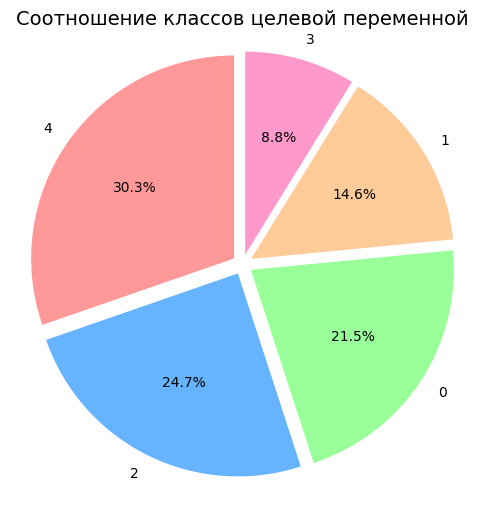

In [55]:
# Считаем количество значений

counts = df_merged['age_category'].value_counts()
labels_age = df_merged['age_category'].unique()

# Строим круговую диаграмму
plt.figure(figsize=(6, 6))
plt.pie(counts.values,
        labels=labels_age,
        autopct='%1.1f%%',  # Показываем проценты
        colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc'],
        explode=(0.05, 0.05, 0.05, 0.05, 0.05), 
        startangle=90)

plt.title('Соотношение классов целевой переменной', fontsize=14)
plt.axis('equal')
plt.show()

In [56]:
# Колонка user_id не требуется для построения модели, по ней мы определили список уникальных записей, теперь ее можно удалить
df_fin = df_merged.drop('user_id', axis=1)

In [57]:
# Признак cloud_usage является бинарным, но содержит пропуски. Приведем его к целочисленному виду, заполнив пропуски отдельным значением 2

df_fin['cloud_usage_encoded'] = df_fin['cloud_usage'].map({
    True: 1,
    False: 0,
    np.nan: 2
    })

In [58]:
# Удаляем исходный признак cloud_usage и проверяем

df_fin = df_fin.drop('cloud_usage', axis=1)
df_fin.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age_category         5826 non-null   int64  
 1   session_count        5826 non-null   int64  
 2   вечер                5826 non-null   float64
 3   день                 5826 non-null   float64
 4   ночь                 5826 non-null   float64
 5   утро                 5826 non-null   float64
 6   Category 01          5826 non-null   float64
 7   Category 02          5826 non-null   float64
 8   Category 03          5826 non-null   float64
 9   Category 04          5826 non-null   float64
 10  Category 05          5826 non-null   float64
 11  Category 06          5826 non-null   float64
 12  Category 07          5826 non-null   float64
 13  Category 08          5826 non-null   float64
 14  Category 09          5826 non-null   float64
 15  Category 10          5826 non-null   float64
 16 

In [59]:
# Определим интервальные колонки:
interval_columns = ['age_category', 'session_count', 'вечер', 'день', 'ночь', 'утро', 
                    'Category 01', 'Category 02', 'Category 03', 'Category 04', 'Category 05', 
                    'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 
                    'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 
                    'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 
                    'website_category', 'cloud_usage_encoded']

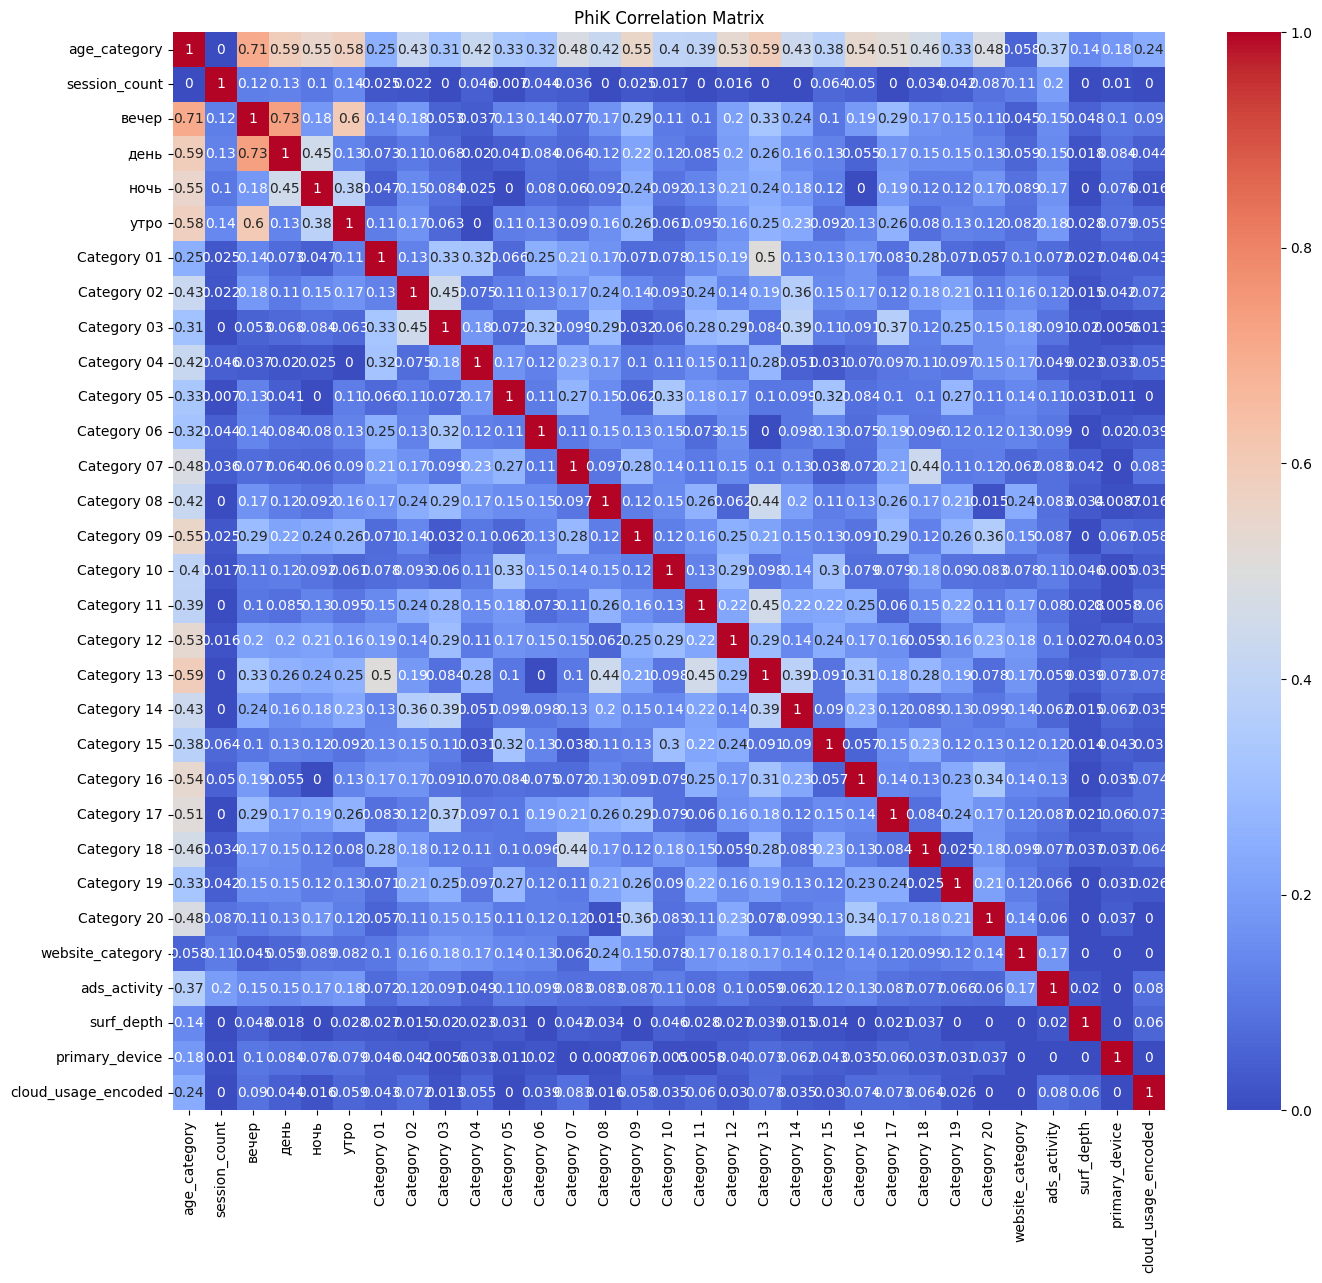

In [60]:
# Построим корелляционную матрицу, чтобы посмотреть корелляцию между переменными

corr_matrix = df_fin.phik_matrix(bins=5, interval_cols = interval_columns)

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('PhiK Correlation Matrix')
plt.show()

Сильно кореллирующих между собой категорий не обнаружено, потому удалять признаки на этом этапе не будем

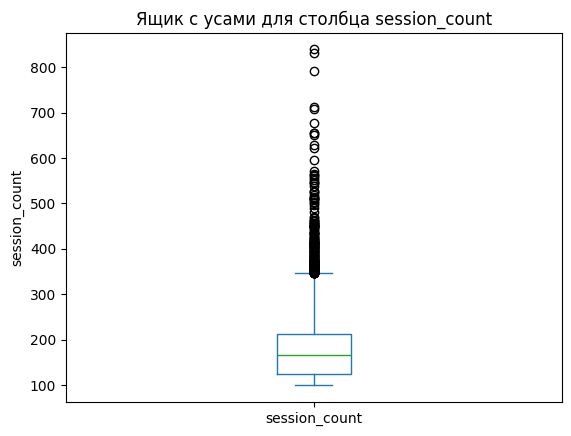

In [61]:
# Исследуем на аномальные выбросы колонку session_count, построим по ней "ящик с усами"

df_fin['session_count'].plot(kind='box')
plt.title(f"Ящик с усами для столбца session_count")
plt.ylabel(f"session_count")
plt.show()

In [62]:
# Также выведем статистику
df_fin['session_count'].describe()

count    5826.000000
mean      180.225712
std        75.186802
min       100.000000
25%       124.000000
50%       167.000000
75%       213.000000
max       839.000000
Name: session_count, dtype: float64

Выбросы по признаку есть, однако, максимальное число сессий 853 укладывается в рамки здравого смысла, потому с выбросами ничего делать не будем.

Таким образом, мы подготовили датасет для предобработки и обучения модели. Датасет содержит 7 признаков и целевую переменную.
Признак best_category потребует Target Encoder, так как в нем 20 уникальных значений и при использовании OneHot - получим слишком много признаков.
Также некоторые признаки потребуют обработки пропусков. 
Из матрицы корелляции можно сделать вывод, что признаков, кореллирующих между собой не обнаружено, некоторые признаки - best_category, best_daytime, ads_activity -  явно кореллируют с целевой переменной 

## Предобработка данных

### Разделение данных

In [63]:
# Разделим выборку на обучающую и тестовую. 
# Отдельно валидационную выборку выделять не будем, тк обучать модель будем на кроссфолдовой валидации

# Сначала разделим целевую переменную и матрицу признаков

X = df_fin.drop('age_category', axis=1)
y = df_fin['age_category']

In [64]:
# Проверка
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_count        5826 non-null   int64  
 1   вечер                5826 non-null   float64
 2   день                 5826 non-null   float64
 3   ночь                 5826 non-null   float64
 4   утро                 5826 non-null   float64
 5   Category 01          5826 non-null   float64
 6   Category 02          5826 non-null   float64
 7   Category 03          5826 non-null   float64
 8   Category 04          5826 non-null   float64
 9   Category 05          5826 non-null   float64
 10  Category 06          5826 non-null   float64
 11  Category 07          5826 non-null   float64
 12  Category 08          5826 non-null   float64
 13  Category 09          5826 non-null   float64
 14  Category 10          5826 non-null   float64
 15  Category 11          5826 non-null   float64
 16 

In [65]:
y.info()

<class 'pandas.Series'>
RangeIndex: 5826 entries, 0 to 5825
Series name: age_category
Non-Null Count  Dtype
--------------  -----
5826 non-null   int64
dtypes: int64(1)
memory usage: 45.6 KB


In [66]:
# Разделяем выборку в пропорции 75 / 25 и используем стратификацию по целевой переменной

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

In [67]:
# Проверим разбивку
print(f"В обучающей выборке признаков {X_train_val.shape[0]} значений")
print(f"В тестовой выборке тестовых признаков {X_test.shape[0]} значений")

print(f"В обучающей выборке по целевой переменной {y_train_val.shape[0]} значений: {y_train_val.value_counts(normalize=True)}")
print(f"В тестовой выборке по целевой переменной {y_test.shape[0]} значений: {y_test.value_counts(normalize=True)}")

В обучающей выборке признаков 4369 значений
В тестовой выборке тестовых признаков 1457 значений
В обучающей выборке по целевой переменной 4369 значений: age_category
4    0.303044
2    0.246967
3    0.215152
0    0.146487
1    0.088350
Name: proportion, dtype: float64
В тестовой выборке по целевой переменной 1457 значений: age_category
4    0.303363
2    0.247083
3    0.215511
0    0.146191
1    0.087852
Name: proportion, dtype: float64


### Подготовка пайплайнов для предобработки

In [68]:
# Сначала разделим признаки по типам

num_features = X_train_val.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_features)

['session_count', 'вечер', 'день', 'ночь', 'утро', 'Category 01', 'Category 02', 'Category 03', 'Category 04', 'Category 05', 'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20', 'website_category', 'cloud_usage_encoded']


In [69]:
cat_features = X_train_val.select_dtypes(include=['str']).columns.tolist()
print(cat_features)

['ads_activity', 'surf_depth', 'primary_device']


In [70]:
# Разделим категориальные признаки на высококардиальные (для TargetEncoder) и низкокардиальные (для OneHotEncoder)

cat_high_features = []
cat_low_features = []

for col in cat_features:
    if X_train_val[col].nunique() > 10:
        cat_high_features.append(col)
    else:
        cat_low_features.append(col)

print(f"Высококардиальные признаки: {cat_high_features}")
print(f"Низкокардиальные признаки: {cat_low_features}")

Высококардиальные признаки: []
Низкокардиальные признаки: ['ads_activity', 'surf_depth', 'primary_device']


In [71]:
# Масштабирование числовых признаков
num_scaler = StandardScaler()

# Заполнение пропусков по числовым признакам
num_imputer = SimpleImputer(strategy='median')

# Кодирование низкокардиальных категориальных признаков. Удаление первой колонки для избежания Dummy ловушки
cat_low_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first') 

# Заполнение пропусков самым часто встречающимся значением (только по обучающей выборке) по низкокардиальным признакам
cat_low_imputer = SimpleImputer(strategy='most_frequent')

# Кодирование высококардиальных категориальных признаков
cat_high_encoder = TargetEncoder(smooth='auto', shuffle=True, random_state=RANDOM_STATE) 

# Заполнение пропусков по высококардиальным категориальным признакам
cat_high_imputer = SimpleImputer(strategy='most_frequent')


In [72]:
# Подготовим пайплайны и ColumnTransformer

# Для числовых признаков
num_pipeline = Pipeline(steps=[
    ('num_imputer', num_imputer),
    ('scale_nums', num_scaler)
])

cat_low_pipeline = Pipeline(steps=[
    ('cat_low_imputer', cat_low_imputer),
    ('cat_low_encoder', cat_low_encoder)
])

cat_high_pipeline = Pipeline(steps=[
    ('cat_high_imputer', cat_high_imputer),
    ('cat_high_encoder', cat_high_encoder)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_features),
        ('cat_low_pipeline', cat_low_pipeline, cat_low_features),
        ('cat_high_pipeline', cat_high_pipeline, cat_high_features)
    ]
)

## Обучение и оценка базовой модели

В качестве базовой модели выберем DummyClassifier. Инициализируем и обучим эту модель

In [73]:
# Создаем DummyClassifier

dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)

# Обучаем 
dummy.fit(X_train_val, y_train_val)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'stratified'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [74]:
# Создадим список для добавления туда результатов оценок

results = []

In [75]:
# Предскажем значения на обучающей выборке

y_pred_dummy = dummy.predict(X_train_val)

# Запрошенные метрики (сохраним в датафрейм)
f1 = f1_score(y_train_val, y_pred_dummy, average='macro')
precision = precision_score(y_train_val, y_pred_dummy, average='macro')
recall = recall_score(y_train_val, y_pred_dummy, average='macro')

results.append({
    "model": 'DummyClassifier',
    "F1": [f1],
    "precision": [precision],
    "recall": [recall]
})

print(results)

[{'model': 'DummyClassifier', 'F1': [0.19838466981786435], 'precision': [0.19848612169417965], 'recall': [0.19839753419107745]}]


## Создание и отбор признаков

### Фильтрационные методы

В рамках предварительного анализа были добавлены признаки: Среднее количество сессий на пользователя, самая популярная категория сайтов для пользователя, и лучшее время суток (наиболее частые просмотры). Признак user_id был удален, как не пригодный для построения моделей.
Проведем анализ на наличие константных признаков

In [76]:
numerical_data = X_train_val[num_features]

# Обучаем VarianceThreshold
vs_constant = VarianceThreshold(threshold=0.0) 
vs_constant.fit(numerical_data)

# Находим константные числовые признаки
constant_num_columns = [col for col, keep in zip(num_features, vs_constant.get_support()) if not keep] 
print(constant_num_columns)

[]


Константных признаков нет. Теперь проверим наличие признаков с низкой вариацией (квази-константных) - когда одинаковое значение занимает подавляющее большинство записей. Установим VarianceThreshold = 0.1

In [77]:
# Устанавливаем значение переменной 

vs_quasi = VarianceThreshold(threshold=0.1) 
vs_quasi.fit(numerical_data)
quasi_num_cols = [col for col, keep in zip(num_features, vs_quasi.get_support()) if not keep]

quasi_cat_cols = [col for col in X_train_val.select_dtypes(include=['str']).columns
                  if X_train_val[col].value_counts(normalize=True).iloc[0] > 0.9]

print(f"Квази-константные числовые признаки: {quasi_num_cols}")
print(f"Квази-константные категориальные признаки: {quasi_cat_cols}")

Квази-константные числовые признаки: ['вечер', 'день', 'ночь', 'утро', 'Category 01', 'Category 02', 'Category 03', 'Category 04', 'Category 05', 'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 'Category 11', 'Category 12', 'Category 13', 'Category 14', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 19', 'Category 20']
Квази-константные категориальные признаки: []


Квазиконстантных числовых и категориальных признаков также нет

### Методы-обёртки

Перейдем к методам-оберткам для определения "лишних" признаков в нашем датасете. Применим оптимальный с точки зрения компромиссов к вычислительным затратам метод рекурсивного исключения признаков. В качестве модели для отбора применим логистическую регрессию

In [78]:
# Применим обработку признаков для обучающей выборки
    
processed_data = preprocessor.fit_transform(X_train_val, y_train_val)

# Подготовим название признаков после препроцессора
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num_pipeline__session_count' 'num_pipeline__вечер' 'num_pipeline__день'
 'num_pipeline__ночь' 'num_pipeline__утро' 'num_pipeline__Category 01'
 'num_pipeline__Category 02' 'num_pipeline__Category 03'
 'num_pipeline__Category 04' 'num_pipeline__Category 05'
 'num_pipeline__Category 06' 'num_pipeline__Category 07'
 'num_pipeline__Category 08' 'num_pipeline__Category 09'
 'num_pipeline__Category 10' 'num_pipeline__Category 11'
 'num_pipeline__Category 12' 'num_pipeline__Category 13'
 'num_pipeline__Category 14' 'num_pipeline__Category 15'
 'num_pipeline__Category 16' 'num_pipeline__Category 17'
 'num_pipeline__Category 18' 'num_pipeline__Category 19'
 'num_pipeline__Category 20' 'num_pipeline__website_category'
 'num_pipeline__cloud_usage_encoded'
 'cat_low_pipeline__ads_activity_очень часто'
 'cat_low_pipeline__ads_activity_редко'
 'cat_low_pipeline__ads_activity_умеренно'
 'cat_low_pipeline__ads_activity_часто'
 'cat_low_pipeline__surf_depth_поверхностно'
 'cat_low_pipeline__surf_dept

In [79]:
# Выберем модель для отбора признаков - Логистическая регрессия. Отберем 20 признаков

estimator = LogisticRegression(solver='lbfgs',     
                               max_iter=1000)

# Иницилизация селектора
rfe_selector = RFE(estimator, n_features_to_select=20, step=1)

rfe_selector.fit(processed_data, y_train_val)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LogisticRegre...max_iter=1000)
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",20
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True


In [80]:
# Получаем ранг важности каждого признака (1 - самый важный)

feature_ranking = rfe_selector.ranking_ 

result = pd.DataFrame({
    'Признак': feature_names,
    'Рейтинг': feature_ranking
})

print(result.sort_values(by='Рейтинг'))

                                       Признак  Рейтинг
17                   num_pipeline__Category 13        1
30        cat_low_pipeline__ads_activity_часто        1
29     cat_low_pipeline__ads_activity_умеренно        1
24                   num_pipeline__Category 20        1
22                   num_pipeline__Category 18        1
21                   num_pipeline__Category 17        1
20                   num_pipeline__Category 16        1
19                   num_pipeline__Category 15        1
34    cat_low_pipeline__primary_device_планшет        1
16                   num_pipeline__Category 12        1
14                   num_pipeline__Category 10        1
13                   num_pipeline__Category 09        1
35   cat_low_pipeline__primary_device_смартфон        1
11                   num_pipeline__Category 07        1
1                          num_pipeline__вечер        1
2                           num_pipeline__день        1
12                   num_pipeline__Category 08  

### Финальный набор признаков

Таким образом, можно удалить признак, занявшие последние места: session_count, website_category, surf_depth, Category 04, Category 02, Category 19, Category 14, Category 11, Category 05, Category 01. Остальные признаки, с рейтингом ниже 1, появились уже после препроцессора, и удалить их не получится.

In [81]:
# Сформируем список признаков для дальнейшей работы

columns_to_drop = [
    'session_count', 'website_category', 'surf_depth', 
    'Category 04', 'Category 02', 'Category 19', 'Category 14', 
    'Category 11', 'Category 05', 'Category 01', 'cloud_usage_encoded']

# Отфильтруем обучающую и тестовую выборки

X_train_val_fin = X_train_val.drop(columns=columns_to_drop)
X_test_fin = X_test.drop(columns=columns_to_drop)

# Проверка
X_train_val_fin.info()

<class 'pandas.DataFrame'>
Index: 4369 entries, 5682 to 5471
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   вечер           4369 non-null   float64
 1   день            4369 non-null   float64
 2   ночь            4369 non-null   float64
 3   утро            4369 non-null   float64
 4   Category 03     4369 non-null   float64
 5   Category 06     4369 non-null   float64
 6   Category 07     4369 non-null   float64
 7   Category 08     4369 non-null   float64
 8   Category 09     4369 non-null   float64
 9   Category 10     4369 non-null   float64
 10  Category 12     4369 non-null   float64
 11  Category 13     4369 non-null   float64
 12  Category 15     4369 non-null   float64
 13  Category 16     4369 non-null   float64
 14  Category 17     4369 non-null   float64
 15  Category 18     4369 non-null   float64
 16  Category 20     4369 non-null   float64
 17  ads_activity    4193 non-null   str    
 18  p

In [82]:
# После фильтрации признаков переопределим наборы колонок и препроцессор

num_features = X_train_val_fin.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(num_features)

cat_features = X_train_val_fin.select_dtypes(include=['str']).columns.tolist()
print(cat_features)

# Разделим категориальные признаки на высококардиальные (для TargetEncoder) и низкокардиальные (для OneHotEncoder)

cat_high_features = []
cat_low_features = []

for col in cat_features:
    if X_train_val[col].nunique() > 10:
        cat_high_features.append(col)
    else:
        cat_low_features.append(col)

print(f"Высококардиальные признаки: {cat_high_features}")
print(f"Низкокардиальные признаки: {cat_low_features}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_features),
        ('cat_low_pipeline', cat_low_pipeline, cat_low_features),
        ('cat_high_pipeline', cat_high_pipeline, cat_high_features)
    ]
)


['вечер', 'день', 'ночь', 'утро', 'Category 03', 'Category 06', 'Category 07', 'Category 08', 'Category 09', 'Category 10', 'Category 12', 'Category 13', 'Category 15', 'Category 16', 'Category 17', 'Category 18', 'Category 20']
['ads_activity', 'primary_device']
Высококардиальные признаки: []
Низкокардиальные признаки: ['ads_activity', 'primary_device']


## Подбор гиперпараметров моделей

### Подготовка

Следующий этап — построение моделей, использующих три подхода к решению многоклассовой задачи:
1. One-vs-Rest;
2. One-vs-One;
3. Многоклассовая логистическая регрессия.

In [83]:
# Сконфигурируем общий кросс-валидатор

cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

### One-vs-Rest модель

In [84]:
# Создаем пайплайн

OVR_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", OneVsRestClassifier(LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')))
])

# Выполним кросс валидацию на модели

result_OVR = cross_validate(OVR_pipeline, X_train_val_fin, y_train_val, scoring=["f1_macro", "precision_macro", "recall_macro"], cv=cv) 

In [85]:
# Сохраним результаты

results.append({
    "model": 'One-vs-Rest',
    "F1": result_OVR['test_f1_macro'].mean(),
    "precision": result_OVR['test_precision_macro'].mean(),
    "recall": result_OVR['test_recall_macro'].mean()
})

# Проверка

print(results)

[{'model': 'DummyClassifier', 'F1': [0.19838466981786435], 'precision': [0.19848612169417965], 'recall': [0.19839753419107745]}, {'model': 'One-vs-Rest', 'F1': np.float64(0.7749913917944706), 'precision': np.float64(0.7721788907578345), 'recall': np.float64(0.7795278905970956)}]


### One-vs-One модель

In [86]:
# Создаем пайплайн

OVO_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", OneVsOneClassifier(LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')))
])

# Выполним кросс валидацию на модели

result_OVO = cross_validate(OVO_pipeline, X_train_val_fin, y_train_val, scoring=["f1_macro", "precision_macro", "recall_macro"], cv=cv) 

In [87]:
# Сохраним результаты

results.append({
    "model": 'One-vs-One',
    "F1": result_OVO['test_f1_macro'].mean(),
    "precision": result_OVO['test_precision_macro'].mean(),
    "recall": result_OVO['test_recall_macro'].mean()
})

# Проверка

print(results)

[{'model': 'DummyClassifier', 'F1': [0.19838466981786435], 'precision': [0.19848612169417965], 'recall': [0.19839753419107745]}, {'model': 'One-vs-Rest', 'F1': np.float64(0.7749913917944706), 'precision': np.float64(0.7721788907578345), 'recall': np.float64(0.7795278905970956)}, {'model': 'One-vs-One', 'F1': np.float64(0.7887971662024743), 'precision': np.float64(0.7846358008491868), 'recall': np.float64(0.7985440076754553)}]


### Многоклассовая логистическая регрессия

In [88]:
# Создаем пайплайн

LR_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor), 
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        solver="lbfgs",
        class_weight='balanced'
))
])

# Выполним кросс валидацию на модели

result_LR = cross_validate(LR_pipeline, X_train_val_fin, y_train_val, scoring=["f1_macro", "precision_macro", "recall_macro"], cv=cv) 

In [89]:
# Сохраним результаты

results.append({
    "model": 'Logistic Regresion',
    "F1": result_LR['test_f1_macro'].mean(),
    "precision": result_LR['test_precision_macro'].mean(),
    "recall": result_LR['test_recall_macro'].mean()
})

# Проверка

print(results)

[{'model': 'DummyClassifier', 'F1': [0.19838466981786435], 'precision': [0.19848612169417965], 'recall': [0.19839753419107745]}, {'model': 'One-vs-Rest', 'F1': np.float64(0.7749913917944706), 'precision': np.float64(0.7721788907578345), 'recall': np.float64(0.7795278905970956)}, {'model': 'One-vs-One', 'F1': np.float64(0.7887971662024743), 'precision': np.float64(0.7846358008491868), 'recall': np.float64(0.7985440076754553)}, {'model': 'Logistic Regresion', 'F1': np.float64(0.7877906463468339), 'precision': np.float64(0.7838808685246436), 'recall': np.float64(0.7973454900722589)}]


### Сравнение результатов

In [90]:
results_df = pd.DataFrame(results)
display(results_df)

,model,F1,precision,recall
0,DummyClassifier,[0.19838466981786435],[0.19848612169417965],[0.19839753419107745]
1,One-vs-Rest,0.774991,0.772179,0.779528
2,One-vs-One,0.788797,0.784636,0.798544
3,Logistic Regresion,0.787791,0.783881,0.797345


Можно сделать вывод, что даже до подбора гиперпараметров - все три модели соответствуют критерию F1 > 0.75, и значительно лучше Dummy модели.
Наилучшие показатели у модели One-vs-One - F1 = 0.784305	

### Подбор гиперпараметров для моделей

#### 6.6.1 Логистическая регрессия

In [91]:
# Создадим словарь для сохранения лучших моделей, и пустой список для результатов: 

best_models = {}
results_grid = []

# Задаем список пайплайнов для исследования

pipelines = {
    "OVR_model": {
        "pipeline": OVR_pipeline,
        "param_grid": {"model__estimator__C": [0.01, 0.1, 1, 10]}
    },
    "OVO_model": {
        "pipeline": OVO_pipeline,
        "param_grid": {"model__estimator__C": [0.01, 0.1, 1, 10]}
    },
    "LR_model": {
        "pipeline": LR_pipeline,
        "param_grid": {"model__C": [0.01, 0.1, 1, 10]}
    }
}

# Создадим цикл для обучения каждой из моделей и вывода результатов

for name, item in pipelines.items():
    pipeline = item["pipeline"]
    param_grid = item["param_grid"]
    
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1)
    # Обучаем 
    grid.fit(X_train_val, y_train_val)

    # Берем лучшие значения
    print(name)
    print("=" * 40)
    print(f"Лучшие параметры по пайплайну:", grid.best_params_)
    print(f"Лучшая метрика по пайплайну:", grid.best_score_)
    best_models[name] = grid.best_estimator_
    print("=" * 40)
    print("\n")
    
    results_grid.append({
        "pipeline": name,
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    })

Fitting 5 folds for each of 4 candidates, totalling 20 fits
OVR_model
Лучшие параметры по пайплайну: {'model__estimator__C': 0.01}
Лучшая метрика по пайплайну: 0.7788859475818821


Fitting 5 folds for each of 4 candidates, totalling 20 fits
OVO_model
Лучшие параметры по пайплайну: {'model__estimator__C': 10}
Лучшая метрика по пайплайну: 0.7893146683354085


Fitting 5 folds for each of 4 candidates, totalling 20 fits
LR_model
Лучшие параметры по пайплайну: {'model__C': 1}
Лучшая метрика по пайплайну: 0.7877906463468339




#### 6.6.2 Метод опорных векторов

Также проведем подбор гиперпараметров, обучив модель методом опорных векторов, используя кросс-валидацию и GridSearch

In [92]:
# Подготовим пайплайны для SVC

OVR_svc_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), 
           ('model', OneVsRestClassifier(SVC(class_weight='balanced', probability=False, random_state=RANDOM_STATE)))])

OVO_svc_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), 
           ('model', OneVsOneClassifier(SVC(class_weight='balanced', probability=False, random_state=RANDOM_STATE)))])

In [93]:
# Создадим словарь для сохранения лучших SVC моделей, и пустой список для результатов: 

best_svc_models = {}
results_svc_grid = []

# Подготовим словарь с параметрами для подбора

pipelines_svc = {
    "OVR_svc_model": {
        "pipeline": OVR_svc_pipeline,
        "param_grid": {
            "model__estimator__kernel": ["linear", "rbf", "poly"],
            "model__estimator__C": [0.1, 1, 10, 100]
        }
    },
    "OVO__svc_model": {
        "pipeline": OVO_svc_pipeline,
        "param_grid": {
            "model__estimator__kernel": ["linear", "rbf", "poly"],
            "model__estimator__C": [0.1, 1, 10, 100]
        }
    }
}

In [94]:
# Создадим цикл для обучения каждой из SVC-моделей и вывода результатов

for name, item in pipelines_svc.items():
    pipeline = item["pipeline"]
    param_grid = item["param_grid"]
    
    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1)
    # Обучаем 
    grid.fit(X_train_val, y_train_val)

    # Берем лучшие значения
    print(name)
    print("=" * 40)
    print(f"Лучшие параметры по пайплайну:", grid.best_params_)
    print(f"Лучшая метрика по пайплайну:", grid.best_score_)
    best_svc_models[name] = grid.best_estimator_
    print("=" * 40)
    print("\n")
    
    results_svc_grid.append({
        "pipeline": name,
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    })

Fitting 5 folds for each of 12 candidates, totalling 60 fits
OVR_svc_model
Лучшие параметры по пайплайну: {'model__estimator__C': 1, 'model__estimator__kernel': 'rbf'}
Лучшая метрика по пайплайну: 0.8609083801795437


Fitting 5 folds for each of 12 candidates, totalling 60 fits
OVO__svc_model
Лучшие параметры по пайплайну: {'model__estimator__C': 1, 'model__estimator__kernel': 'rbf'}
Лучшая метрика по пайплайну: 0.8571555474487218




Можно сделать вывод, что лучшей моделью после подбора гиперпараметров оказалась модель OVR_svc_model. На этапе подбора удалось улучшить основную метрику F1 - результат 0.8609. Эту модель и будем использовать на тестовых данных

### Проверка лучшей модели на тестовых данных и расчет метрик

In [95]:
# Заберем лучшую модель в отдельную переменную:

final_model = best_svc_models["OVR_svc_model"]

# Предскажем значения на тестовых данных:

y_pred = final_model.predict(X_test_fin)

# Рассчитаем метрики:

f1_fin = f1_score(y_test, y_pred, average='macro')
precision_fin = precision_score(y_test, y_pred, average='macro')
recall_fin = recall_score(y_test, y_pred, average='macro')

print("=" * 40)
print(f"Основная метрика F1 на тестовых данных: {round(f1_fin, 4)}")
print(
    f"Вспомогательные метрики Precision и Recall на тестовых данных: Precision: {round(precision_fin, 4)}, Recall: {round(recall_fin, 4)}")

Основная метрика F1 на тестовых данных: 0.8625
Вспомогательные метрики Precision и Recall на тестовых данных: Precision: 0.8613, Recall: 0.8642


Можно сделать вывод, что на тестовых данных финальная модель показывает сходные результаты с обучением. Данная модель может рекомендоваться для внедрения в продакшн

## Подготовка артефактов модели для внедрения

In [96]:
# Сохраним модель и метаданные с помощью joblib

# Собираем признаки
metadata = {
    'model_version': '1.0',
    'training_date': '2026-03-14',
    'features': X_train_val_fin.columns
}

In [97]:
# Сохраняем препроцессор и лучшую модель
joblib.dump({'preprocessor': preprocessor,
             'metadata': metadata,
             'best_model': final_model
            },
             'yeti_project_model_2.0_15.03.26.joblib')

['yeti_project_model_2.0_15.03.26.joblib']

In [98]:
# Сохраним в отдельный файл функцию, которая соединяет датафреймы

with open("merge_utils.py", "w") as f:
    f.write(inspect.getsource(merge_dfs))

In [99]:
# Проверим загрузку функции из файла

from merge_utils import merge_dfs as merge_user_tables

In [100]:
# Загружаем модель для проверки

loaded_data = joblib.load('yeti_project_model_2.0_15.03.26.joblib')

loaded_model = loaded_data['best_model']
loaded_preprocessor = loaded_data['preprocessor']

In [101]:
# Проверим применение функции мержа таблиц

df_merge_check = merge_user_tables(
    df_users_clean,
    [
        df_visits_fin,
        df_ads_activity_clean,
        df_surf_depth,
        df_primary_device,
        df_cloud_usage
    ])

df_merge_check.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5826 non-null   str    
 1   age_category      5826 non-null   int64  
 2   session_count     5826 non-null   int64  
 3   вечер             5826 non-null   float64
 4   день              5826 non-null   float64
 5   ночь              5826 non-null   float64
 6   утро              5826 non-null   float64
 7   Category 01       5826 non-null   float64
 8   Category 02       5826 non-null   float64
 9   Category 03       5826 non-null   float64
 10  Category 04       5826 non-null   float64
 11  Category 05       5826 non-null   float64
 12  Category 06       5826 non-null   float64
 13  Category 07       5826 non-null   float64
 14  Category 08       5826 non-null   float64
 15  Category 09       5826 non-null   float64
 16  Category 10       5826 non-null   float64
 17  Catego

In [102]:
# Проверим применение загруженного препроцессора к тестовым данным

loaded_preprocessor.fit_transform(X_test_fin)

array([[ 0.25530508, -1.88650134,  1.25048024, ...,  0.        ,
         0.        ,  1.        ],
       [-0.55412638, -0.1554261 ,  0.20702577, ...,  0.        ,
         0.        ,  0.        ],
       [-0.14898883, -0.14714121,  0.85951102, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [ 2.32937858, -1.87089515,  0.1040716 , ...,  0.        ,
         0.        ,  1.        ],
       [ 0.09479987,  1.48602332, -1.08493502, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.06219529,  0.51099999, -0.30378533, ...,  0.        ,
         0.        ,  1.        ]], shape=(1457, 24))

In [103]:
# Проверим предсказание загруженной модели на тестовых данных

loaded_model_predict = loaded_model.predict(X_test_fin)

# Рассчитаем основную метрику F1

f1_loaded = f1_score(y_test, loaded_model_predict, average='macro')
print(round(f1_loaded, 4))

0.8625


Результат загруженной модели совпадает с результатом обученной модели. Таким образом, можно сделать вывод, что сохранение и последующая загрузка успешны. Артефакты можно передавать для работы в продакшне

## Выводы о результатах работы

В рамках работы была решена задача многоклассовой классификации пользователей на основе логов посещения сайтов и дополнительных параметров. Основной целью было построить модель, способную предсказывать целевую категорию пользователя по его интернет-активности.

**Подготовка и анализ данных**

На этапе подготовки данных были выполнены:

- очистка и обработка пропусков;
- кодирование категориальных признаков;
- масштабирование числовых признаков;
- построение дополнительных признаков на основе логов посещений.

Особое внимание было уделено поведенческим характеристикам пользователей, таким как:

- распределение интернет-активности по категориям сайтов;
- распределение активности по времени суток;
- глубина просмотра;
- интенсивность использования сервисов.

Создание агрегированных признаков позволило более полно описать поведенческий профиль пользователя.

**Моделирование**

Для решения задачи были обучены несколько моделей:

- логистическая регрессия (multinomial);
- One-vs-Rest классификатор;
- One-vs-One классификатор.

Для оценки качества использовалась кросс-валидация, а оптимальные гиперпараметры моделей подбирались с помощью GridSearchCV.

Основной метрикой качества была выбрана F1-мера (macro), так как задача является многоклассовой и классы могут быть несбалансированы.

**Результаты**

По итогам экспериментов:

- все модели показали сопоставимое качество;
- наилучшие результаты продемонстрировала модель с оптимально подобранным параметром регуляризации C;
- использование кросс-валидации позволило получить устойчивую оценку качества моделей.

Дополнительно был проведён анализ важности признаков, который показал, что наибольший вклад в предсказание вносят:

- распределение активности по категориям сайтов;
- время суток, в которое пользователь наиболее активен;
- глубина и интенсивность интернет-сессий


**Итоги**

Построенная модель успешно решает задачу классификации пользователей на основе логов посещений. Результаты показывают, что использование агрегированных поведенческих признаков значительно повышает качество предсказаний.

В дальнейшем качество модели может быть улучшено за счёт:

- расширения набора поведенческих признаков;
- дополнительной настройки гиперпараметров моделей.